In [40]:
%pip install psycopg2-binary

import psycopg2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📊 SQL Analysis & Business Insights

## 📌 Objective

This notebook connects the cleaned dataset to PostgreSQL and performs SQL-based analysis to extract meaningful business insights.

---

---

## 📂 Tasks Performed

- Install required packages
- Connect to PostgreSQL
- Create database connection
- Create cursor
- Explore table schema
- Execute SQL queries
- Analyze customer ordering behavior
- Analyze revenue patterns
- Analyze city-wise performance
- Generate business insights
- Display results in tabular format

---

---

## 📚 Libraries Used

- psycopg2
- pandas
- Tabulate
---

In [41]:
#Connection with database
connection = psycopg2.connect(
    host="localhost",
    database="student_db",
    user="postgres",
    password="roneet",
    port="5432"
)

In [42]:
# Cursor Formation
cursor = connection.cursor()

In [43]:
# Check the name of the columns
cursor.execute("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'food_orders';
""")

columns = cursor.fetchall()

for column in columns:
    print(column)

('order_id',)
('user_id',)
('age',)
('city',)
('order_time',)
('day_type',)
('cuisine',)
('meal_type',)
('restaurant_type',)
('order_value',)
('discount_applied',)
('delivery_fee',)
('time_taken_to_order',)
('rating_given',)
('is_repeat_order',)
('company',)
('rainy_weather',)
('temperature',)
('humidity',)
('rain',)
('wind_speed',)


In [44]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## 📊 Analysis Includes

- Customer Analysis
- Revenue Analysis
- City-wise Analysis
- Restaurant Performance
- Weather Impact Analysis *(if applicable)*
- Business Insights

---

In [45]:
import pandas as pd

def execute_query(query):
    try:
        cursor.execute(query)

        # SELECT query ke liye
        if cursor.description:
            rows = cursor.fetchall()

            # Column names
            columns = [desc[0] for desc in cursor.description]

            # DataFrame
            df = pd.DataFrame(rows, columns=columns)

            # Table print
            # print(df)

            return df

        connection.commit()
        print("✅ Query Executed Successfully")

    except Exception as e:
        connection.rollback()
        print("❌ Query Failed")
        print(e)

 # 📊 Business Meeting

- Level 1 (Basic KPI)

In [46]:
# Q1. How many total orders did we receive?

query = """
    SELECT
        COUNT(DISTINCT order_id) AS total_orders
    FROM food_orders;
"""
# print('Total Orders :',end='')
execute_query(query)


,total_orders
0,50000


In [47]:
# Q2. What is our total revenue?

query = """
SELECT  
    SUM(delivery_fee + order_value)
FROM food_orders;
"""

# print('Total Revenue :',end='')
execute_query(query)

,sum
0,30368691


In [48]:
# Q3. What is the average order value?
query = """
SELECT  
    ROUND(AVG(delivery_fee + order_value),2) AS avg_order_value
FROM food_orders;
"""

print('Average Order Revenue :',end='')
execute_query(query)


Average Order Revenue :

,avg_order_value
0,607.37


In [49]:
# Q4. Which city generated the highest revenue?

query = """
SELECT 
    city,
    SUM(delivery_fee + order_value)  AS revenue
FROM food_orders
GROUP BY city
ORDER BY revenue DESC 
LIMIT 1;
"""

print('City Generated Highest Revenue :',end='')
execute_query(query)


City Generated Highest Revenue :

,city,revenue
0,Mumbai,4906594


In [50]:
# Q5. Which cuisine is the most popular?
query = """
SELECT 
    cuisine,
    SUM(rating_given) AS popular
FROM food_orders
GROUP BY cuisine
ORDER BY popular DESC 
LIMIT 1;
"""
print('Most popular Cusine :',end='')
execute_query(query)


Most popular Cusine :

,cuisine,popular
0,Desserts,24123


In [51]:
# Q6. Which meal time (Breakfast/Lunch/Dinner/Snacks) receives the most orders?
query = """
SELECT 
    meal_type,
    COUNT(DISTINCT order_id) AS most_order
FROM food_orders
GROUP BY meal_type
ORDER BY most_order DESC
Limit 1;
"""
print('Meal time recive most order :',end='')
execute_query(query)


Meal time recive most order :

,meal_type,most_order
0,Breakfast,11953


In [52]:
# Q7.What is the average customer rating?

query = """
SELECT 
    ROUND(AVG(rating_given),2)
FROM food_orders;
"""
print('Average Customer Rating :',end='')
execute_query(query)

Average Customer Rating :

,round
0,2.99


In [53]:
# Q8.Which restaurant type receives the highest number of orders?

query = """
SELECT 
    restaurant_type,
    COUNT(DISTINCT order_id) AS No_of_orders
FROM food_orders
GROUP BY restaurant_type
ORDER BY No_of_orders DESC
LIMIT 1;
"""

print('Famous Restaurant :',end='')
execute_query(query)

Famous Restaurant :

,restaurant_type,no_of_orders
0,Premium,15973


- Level 2 (Business Thinking)

In [54]:
# Customers complain about late deliveries.

# Which city has the highest average delivery time?

query = """
SELECT 
    city,
    ROUND(AVG(time_taken_to_order),2) AS highest_avg_del
FROM food_orders
GROUP BY city
ORDER BY highest_avg_del DESC
LIMIT 2;    
"""
print('Highest Average Delivery Time : ', end='')
execute_query(query)



Highest Average Delivery Time : 

,city,highest_avg_del
0,Pune,7.54
1,Chandigarh,7.54


In [55]:
# Q10. Does rain affect delivery time?

query = """
SELECT 
    rainy_weather,
    COUNT(*) AS total_orders,
    ROUND(AVG(time_taken_to_order),2) AS avg_time,
    MIN(time_taken_to_order) AS fastest,
    MAX(time_taken_to_order) AS slowest
FROM food_orders
GROUP BY rainy_weather
ORDER BY total_orders DESC;
"""
print('Rain affect delivery time : ')
execute_query(query)


Rain affect delivery time : 


,rainy_weather,total_orders,avg_time,fastest,slowest
0,Yes,23767,7.51,1,14
1,No,23733,7.48,1,14
2,Unknown,2500,7.58,1,14


In [56]:
# Q11. Which order time has the highest revenue?

query = """ 
SELECT 
    order_time,
    ROUND(SUM(order_value),2) AS highest_revenue
FROM food_orders
GROUP BY order_time
ORDER BY highest_revenue DESC
LIMIT 1;
"""
print('The highest Order Time :')
execute_query(query)


The highest Order Time :


,order_time,highest_revenue
0,Evening,6564364.00


In [57]:
# Q12. Which company receives better ratings?

query = """
SELECT 
    company,
    ROUND(AVG(rating_given),2) AS better_ratings
FROM food_orders
GROUP BY company
ORDER BY better_ratings DESC
LIMIT 1;
"""

print('Company Recive Better Ratings :')
execute_query(query)


Company Recive Better Ratings :


,company,better_ratings
0,Swiggy,3.02


In [58]:
# Q13. Does giving discounts increase revenue?

query = """
SELECT 
    discount_applied,
    SUM(delivery_fee + order_value) AS revenue
FROM food_orders
GROUP BY discount_applied
ORDER BY revenue DESC;
"""
print('Giving Discount Increase Revenue :')
execute_query(query)

Giving Discount Increase Revenue :


,discount_applied,revenue
0,Yes,14464340
1,No,14373495
2,Unknown,1530856


In [59]:
# Q14. Which city gives the highest average order value?

query = """
SELECT 
    city,
   ROUND(AVG(order_value),2) AS avg_order_value
FROM food_orders
GROUP BY city
ORDER BY avg_order_value DESC
LIMIT 1;
"""
print('Highest Average Order Value :')
execute_query(query)

Highest Average Order Value :


,city,avg_order_value
0,Pune,552.02


In [60]:
# Q15.Which cuisine has the highest average rating?

query = """
WITH TOP_RATING AS(
    SELECT 
        cuisine,
        ROUND(AVG(rating_given),2) AS rating,
        DENSE_RANK()
        OVER(
            ORDER BY ROUND(AVG(rating_given),2) DESC
        ) AS cuisine_rank
    FROM food_orders
    GROUP BY cuisine
)
SELECT  
    cuisine,
    rating
FROM TOP_RATING
WHERE cuisine_rank = 1
;
"""
print('Highest Rated Cuisine :')
execute_query(query)

Highest Rated Cuisine :


,cuisine,rating
0,North Indian,3.00
1,Chinese,3.00
2,South Indian,3.00
3,Desserts,3.00


- Level 3 (Manager Questions)

In [61]:
# Q16.
# We want to expand into one city.
# Which city would you recommend and why?
# Support your answer with data.

query = """
SELECT 
    city,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(*) AS total_orders,
    ROUND(AVG(order_value),2) AS avg_order,
    ROUND(AVG(time_taken_to_order),2) AS avg_delivery_time,
    ROUND(AVG(rating_given),2) AS avg_rating,
     COUNT(*) AS repeat_orders
FROM food_orders
GROUP BY city
ORDER BY revenue DESC
"""
# print('Expand in city :')
execute_query(query)


,city,revenue,total_orders,avg_order,avg_delivery_time,avg_rating,repeat_orders
0,Mumbai,4906594,8041,550.38,7.44,3.01,8041
1,Pune,4861137,7949,552.02,7.54,2.99,7949
2,Bangalore,4783290,7930,543.50,7.40,3.00,7930
3,Delhi,4778663,7902,545.14,7.53,2.99,7902
4,Hyderabad,4764466,7834,548.45,7.53,3.00,7834
5,Chandigarh,4751722,7844,545.98,7.54,2.99,7844
6,Unknown,1522819,2500,550.43,7.52,2.97,2500


In [62]:
# Q17.
# Delivery is becoming expensive.
# Should we increase delivery fees?
# Use data to justify your answer.

query = """
SELECT 
    ROUND(AVG(delivery_fee),2)
FROM food_orders;  
"""
execute_query(query)

# No Our Average delivery fees is just 60 rupees is better to not increase deleivery fees 

,round
0,59.64


In [63]:
# Q18.

# Which customer segment should Marketing target?

# Think using

# age

query = """
SELECT 
    age,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer
FROM food_orders 
WHERE is_repeat_order = 'Yes'
GROUP BY age;
"""
# City
execute_query(query)
query = """
SELECT 
    city,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer
FROM food_orders 
WHERE is_repeat_order = 'Yes'
GROUP BY city;
"""
execute_query(query)
# Meal Type
query = """
SELECT 
    meal_type,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer
FROM food_orders 
WHERE is_repeat_order = 'Yes'
GROUP BY meal_type;
"""
execute_query(query)
# Cuisine
query = """
SELECT 
    cuisine,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer
FROM food_orders 
WHERE is_repeat_order = 'Yes'
GROUP BY cuisine;
"""
execute_query(query)

# Repeat Orders
query = """
SELECT 
    is_repeat_order,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer
FROM food_orders 
WHERE is_repeat_order = 'Yes'
GROUP BY is_repeat_order;
"""
execute_query(query)

,is_repeat_order,revenue,order_count,avg_order_value,avg_rating,repeat_customer
0,Yes,14488857,23752,610,3.00,23752


In [64]:
# Q19.

# When should we run discount campaigns?

# Morning?

# Lunch?

# Dinner?

# Weekend?

# Support using revenue and order count.


query = """
SELECT 
    order_time,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer,
    DENSE_RANK()
    OVER(
        ORDER BY SUM(order_value + delivery_fee) DESC
    ) ranking
FROM food_orders
GROUP BY order_time;
"""
print(execute_query(query))

query = """
SELECT 
    day_type,
    SUM(order_value + delivery_fee) AS revenue,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(order_value + delivery_fee) /
             COUNT(DISTINCT order_id) AS Avg_order_value,
    ROUND(AVG(rating_given),2) AS avg_rating ,
    COUNT(is_repeat_order) AS repeat_customer,
    DENSE_RANK()
    OVER(
        ORDER BY SUM(order_value + delivery_fee) DESC
    ) ranking
FROM food_orders
GROUP BY day_type;
"""
print(execute_query(query))

  order_time  revenue  order_count  avg_order_value avg_rating  \
0    Evening  7274573        11933              609       2.99   
1      Night  7215732        11903              606       2.99   
2    Morning  7197240        11891              605       3.01   
3  Afternoon  7166481        11773              608       2.98   
4    Unknown  1514665         2500              605       3.00   

   repeat_customer  ranking  
0            11933        1  
1            11903        2  
2            11891        3  
3            11773        4  
4             2500        5  
  day_type   revenue  order_count  avg_order_value avg_rating  \
0  Weekday  14456186        23741              608       2.99   
1  Weekend  14401234        23759              606       3.00   
2  Unknown   1511271         2500              604       2.98   

   repeat_customer  ranking  
0            23741        1  
1            23759        2  
2             2500        3  


In [65]:
# Q20.

# Should we increase the number of delivery partners during rainy weather?

query = """
SELECT 
    rainy_weather,
    COUNT(order_id) AS orders,
    AVG(time_taken_to_order) AS time_taken
FROM food_orders
GROUP BY rainy_weather
ORDER BY time_taken DESC;

"""
execute_query(query)



,rainy_weather,orders,time_taken
0,Unknown,2500,7.5804000000000000
1,Yes,23767,7.5094879454706105
2,No,23733,7.4751190325706822


## 🎯 Outcome

SQL queries are used to transform raw transactional data into actionable business insights that support decision-making.

# Visualization

In [ ]:

import matplotlib.pyplot as plt

def bar_chart(x, y,
              title="Bar Chart",
              xlabel="X-axis",
              ylabel="Y-axis",
              figsize=(8,5)):
    
    plt.figure(figsize=figsize)

    bars = plt.bar(x, y)

    # Value labels
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():,.0f}",
            ha="center",
            va="bottom"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

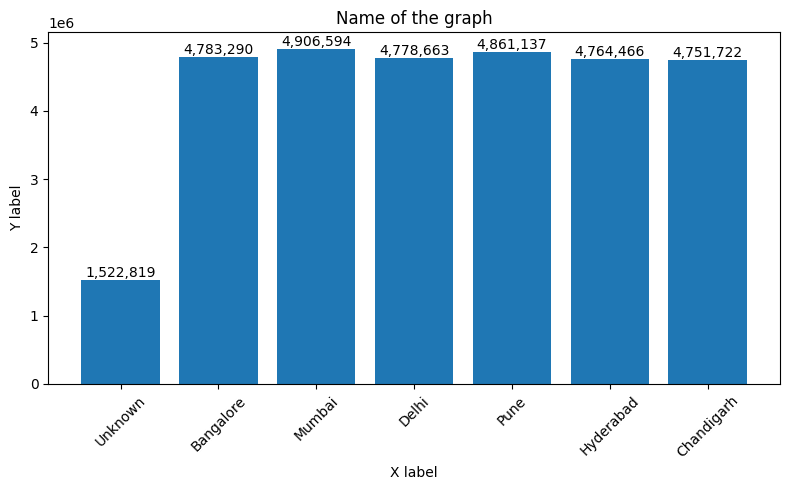

In [ ]:
# Section 1: Dataset Understanding
# 1. Orders by City

# Question:

# Which cities generate the highest number of food orders?

try :
    query = """
    SELECT
        city, 
        SUM(order_value + delivery_fee) AS revenue
    FROM food_orders
    GROUP BY city;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    x = [row[0] for row in rows]
    y = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)


# Step 4: Function Call
bar_chart(
    x,
    y,
    title="Name of the graph",
    xlabel="X label",
    ylabel="Y label"
)

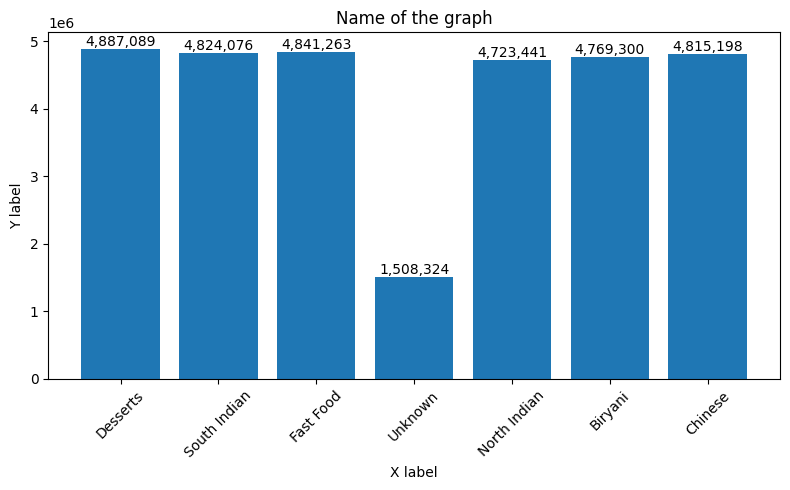

In [67]:
# 2. Popular Cuisine

# Question

# Which cuisine is ordered the most?

try :
    query = """
    SELECT
        cuisine, 
        SUM(order_value + delivery_fee) AS revenue
    FROM food_orders
    GROUP BY cuisine; 
      ;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    x = [row[0] for row in rows]
    y = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)



# Step 3: Reusable Function

import matplotlib.pyplot as plt

def bar_chart(x, y,
              title="Bar Chart",
              xlabel="X-axis",
              ylabel="Y-axis",
              figsize=(8,5)):
    
    plt.figure(figsize=figsize)

    bars = plt.bar(x, y)

    # Value labels
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():,.0f}",
            ha="center",
            va="bottom"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()



# Step 4: Function Call
bar_chart(
    x,
    y,
    title="Name of the graph",
    xlabel="X label",
    ylabel="Y label"
)


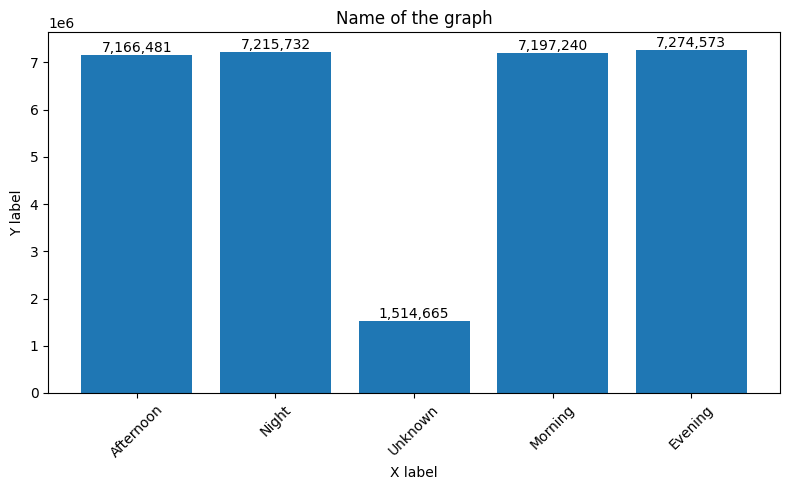

In [68]:
# 3. Meal Time Distribution

# Question

# At what time do people order food the most?

try :
    query = """
    SELECT
        order_time, 
        SUM(order_value + delivery_fee) AS revenue
    FROM food_orders
    GROUP BY order_time;    
      ;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    x = [row[0] for row in rows]
    y = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)



# Step 3: Reusable Function

import matplotlib.pyplot as plt

def bar_chart(x, y,
              title="Bar Chart",
              xlabel="X-axis",
              ylabel="Y-axis",
              figsize=(8,5)):
    
    plt.figure(figsize=figsize)

    bars = plt.bar(x, y)

    # Value labels
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():,.0f}",
            ha="center",
            va="bottom"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()



# Step 4: Function Call
bar_chart(
    x,
    y,
    title="Name of the graph",
    xlabel="X label",
    ylabel="Y label"
)

In [ ]:
# Pie Chart

import matplotlib.pyplot as plt

def pie_chart(labels,
              values,
              title="Pie Chart",
              figsize=(7,7)):

    plt.figure(figsize=figsize)

    plt.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(title)

    plt.axis("equal")

    plt.tight_layout()

    plt.show()

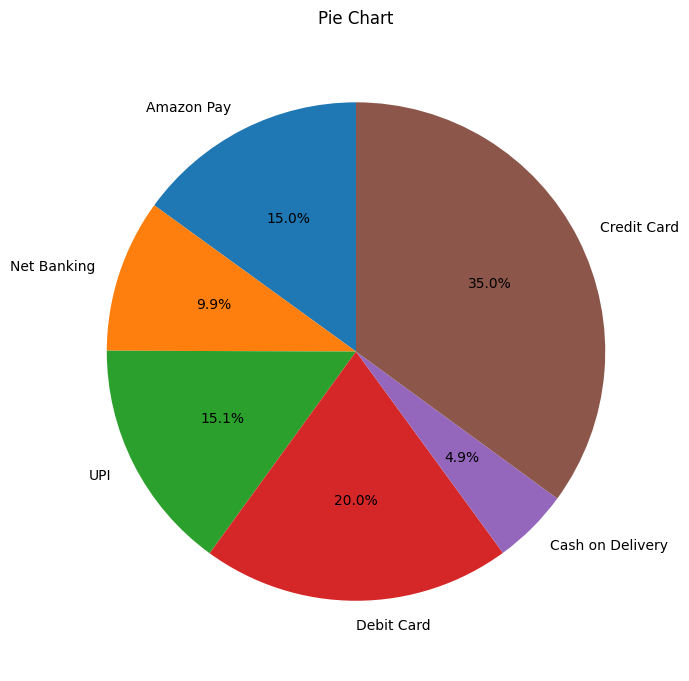

In [70]:
# 4. Payment Method Distribution

# Question

# Which payment method is most popular?

query = """
SELECT
    paymentmethod,
    COUNT(*) AS total_orders
FROM orders
GROUP BY paymentmethod;
"""

cursor.execute(query)

rows = cursor.fetchall()

labels = [row[0] for row in rows]
values = [row[1] for row in rows]

# labels = ['Cash', 'UPI', 'Credit Card']
# values = [50, 20, 30]

pie_chart(labels,values,
        title="Pie Chart",
        figsize=(7,7))





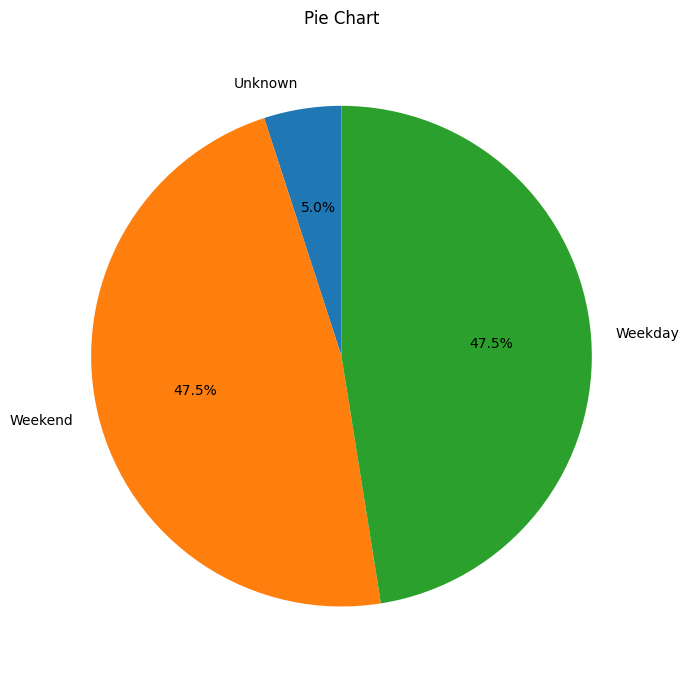

In [74]:
try :
    query = """
    SELECT
        day_type,
        COUNT(*) AS total_orders
    FROM food_orders
    GROUP BY day_type;

    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    labels = [row[0] for row in rows]
    values = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)



pie_chart(labels,
            values,
            title="Pie Chart",
            figsize=(7,7))

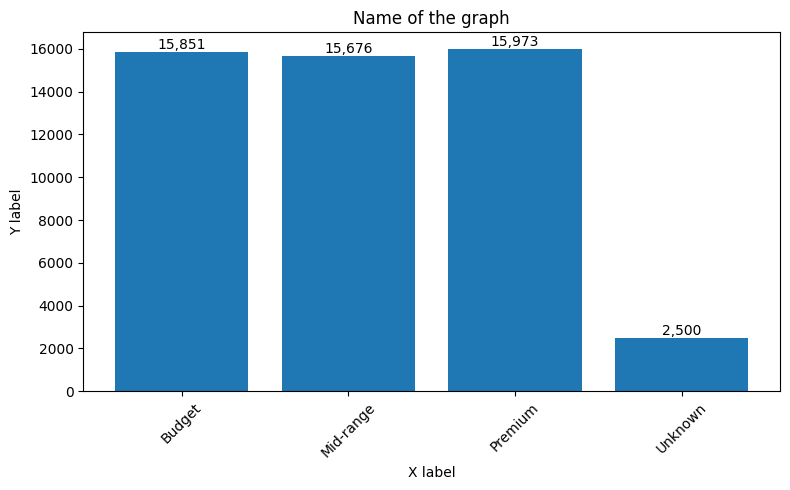

In [77]:
# 6. Spending Category

# Question

# Which spending category has the maximum orders?



try :
    query = """
    SELECT
        restaurant_type,
        COUNT(DISTINCT order_id)
    FROM food_orders
    GROUP BY restaurant_type;
      ;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    x = [row[0] for row in rows]
    y = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)



# Step 4: Function Call
bar_chart(
    x,
    y,
    title="Name of the graph",
    xlabel="X label",
    ylabel="Y label"
)






In [ ]:
# LINE PLOT 

def plot_line(x, y,
              title="Line Chart",
              xlabel="X-axis",
              ylabel="Y-axis",
              figsize=(8,5),
              marker="o"):

    plt.figure(figsize=figsize)

    plt.plot(x, y, marker=marker)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid(True)

    plt.tight_layout()
    plt.show()

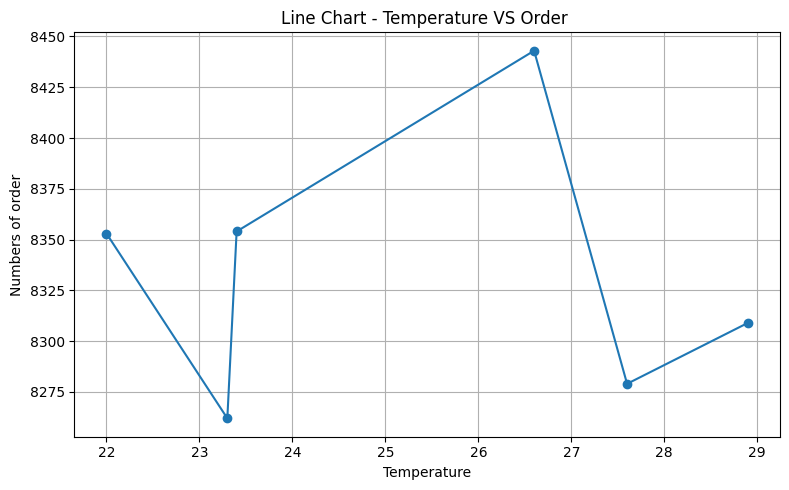

In [84]:
# 7. Temperature vs Orders

# Question

# Does temperature affect food ordering?

try :
    query = """
    SELECT
        temperature,
        COUNT(DISTINCT order_id)
    FROM food_orders
    GROUP BY temperature;
      ;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    x = [row[0] for row in rows]
    y = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)


plot_line(x, y,
    title="Line Chart - Temperature VS Order ",
    xlabel="Temperature",
    ylabel="Numbers of order",
    figsize=(8,5),
    marker="o")

